# Single-influx PDE in 2D (IMEX-FFT, pruned community) — long run to t=4000

2D analogue of notebook 04. Draw a Turing-unstable community, prune extinct strains (exact, since N_i=0 is invariant), integrate the 2D PDE on a periodic domain with the IMEX-FFT stepper (`solve_pde_2d_imex` — diffusion implicit in Fourier space, reaction explicit; no LU / fill-in), **save the trajectory to disk**, and analyse it: total biomass vs time, biomass-field snapshots, and a horizontal slice. The solve is the only expensive step; the plotting cells reload the saved `.npz` so they never re-run it.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_context('talk', rc={'font.size': 15, 'axes.titlesize': 15, 'axes.labelsize': 15})
sns.set_style('whitegrid', {'grid.color': '.9', 'grid.linestyle': '--', 'axes.edgecolor': '.6', 'xtick.bottom': True, 'ytick.left': True})

from ssmc.sampling import JansSampler3, Dirac
from ssmc.linstab import scan_k, classify
from ssmc.solver import solve_steady_state, solve_pde_2d_imex
from ssmc.params import SpatialMiCRMParams
from ssmc.reduce import survivor_mask, prune_strains, prune_state

## 1. Draw a Turing-unstable community

Same sampler as notebook 04; rejection-sample until the dispersion relation is unstable.

In [3]:
def make_sampler(K, l_influx, Dr_byp=1.0, Ns=30, Nr=30):
    return JansSampler3(
        Ns=Ns, Nr=Nr,
        m=stats.lognorm(s=0.3, scale=1.0), r=Dirac(1.0),
        num_influx_resources=1, K=Dirac(K),
        prob_eating=0.7, prob_eating_influx=1.0,
        num_byproducts=Dirac(2),
        c=stats.lognorm(s=0.3, scale=1.0),
        l=stats.uniform(loc=0.3, scale=0.5),
        cinflux=stats.lognorm(s=0.3, scale=1.0),
        linflux=Dirac(l_influx),
        Ds=Dirac(1e-6), Dr=Dirac(Dr_byp), Drinflux=Dirac(1.0),
    )

def draw_unstable(sampler, rng, max_tries=40, ks=None):
    if ks is None:
        ks = np.linspace(1e-3, 500.0, 2000)
    for attempt in range(max_tries):
        sparams = sampler(rng)
        micrm = sparams.micrm
        Ns = micrm.Ns
        u0 = np.concatenate([0.1 * np.ones(Ns), micrm.K / np.maximum(micrm.r, 1e-6)])
        u_ss, ok = solve_steady_state(micrm, u0, t_max=2e3, rtol=1e-7, atol=1e-9)
        if not ok or np.max(u_ss[:Ns]) < 1e-6:
            continue
        res = scan_k(sparams, u_ss, ks)
        if classify(res) == 'unstable':
            return sparams, u_ss, res, attempt + 1
    return None

rng = np.random.default_rng(1)
sampler = make_sampler(K=10.0, l_influx=0.999, Dr_byp=.01)
out = draw_unstable(sampler, rng)
assert out is not None, 'no unstable community found'
sparams, u_ss, dispersion, n_draws = out
k_star = dispersion.max_k
L_star = 2 * np.pi / k_star
print(f'unstable after {n_draws} tries; peak k={k_star:.2f}, L*={L_star:.3f}, max Re lambda={dispersion.max_mrl:.3g}')

unstable after 1 tries; peak k=12.76, L*=0.493, max Re lambda=0.0722


## 2. Prune extinct strains

Only a handful of strains survive the homogeneous fixed point; dropping the extinct ones is exact and shrinks the state.

In [4]:
Ns = sparams.Ns
keep = survivor_mask(u_ss, Ns)
sparams_pruned, keep_idx = prune_strains(sparams, keep)
u_ss_pruned = prune_state(u_ss, Ns, keep_idx)
print(f'survivors: {int(keep.sum())}/{Ns} strains; ntot {sparams.Ns + sparams.Nr} -> {sparams_pruned.Ns + sparams_pruned.Nr}')

survivors: 3/30 strains; ntot 60 -> 33


## 3. 2D periodic domain and initial condition

In [5]:
nx = ny = 128
L_box = 6 * L_star
dx = L_box / nx
sparams_2d = SpatialMiCRMParams(micrm=sparams_pruned.micrm, Ds=sparams_pruned.Ds, dx=dx, bc='periodic')

ntot = sparams_pruned.Ns + sparams_pruned.Nr
rng2 = np.random.default_rng(0)
u0 = np.tile(u_ss_pruned[:, None, None], (1, ny, nx)) * (1.0 + 1e-3 * rng2.standard_normal((ntot, ny, nx)))
print(f'grid {ny}x{nx}, L_box={L_box:.2f}, dx={dx:.4f} (~{L_star/dx:.0f} pts/L*), N={ntot*ny*nx}')

grid 128x128, L_box=2.96, dx=0.0231 (~21 pts/L*), N=540672


## 4. Integrate with IMEX-FFT to t=4000 (200 log-spaced output times)

`dt=0.01` for fine temporal resolution: a 5x smaller step over a 5x shorter window keeps the same ~400k step count and wall-clock (~4-5 hours), and dt=0.01 is comfortably within the stable range.

In [6]:
t_max = 4000.0
dt = 0.01
t_eval = np.logspace(np.log10(1.0), np.log10(t_max), 200)
sol = solve_pde_2d_imex(sparams_2d, u0, t_span=(0.0, t_max), dt=dt, t_eval=t_eval)
print(f'success={sol.success}, message={sol.message}')
print(f'recorded {sol.t.size} times, t in [{sol.t[0]:.2f}, {sol.t[-1]:.0f}]')

success=True, message=completed
recorded 200 times, t in [1.00, 4000]


## 5. Save the trajectory

Plotting below reloads this file, so it is independent of the (expensive) solve above.

In [7]:
np.savez_compressed('20260618_09_sol_t4000.npz',
                    t=sol.t, u=sol.u, dx=dx, Ns_p=sparams_pruned.Ns)
print('saved', sol.u.shape, '-> 20260618_09_sol_t4000.npz')

saved (200, 33, 128, 128) -> 20260618_09_sol_t4000.npz


## 6. Load saved solution

Run from here onward to (re)make any plot without re-integrating.

In [8]:
data = np.load('20260618_09_sol_t4000.npz')
t = data['t']; u = data['u']; dx = float(data['dx']); Ns_p = int(data['Ns_p'])
ny, nx = u.shape[-2], u.shape[-1]
biomass = u[:, :Ns_p].sum(axis=1)   # (nt, ny, nx): total strain biomass field
print('loaded', u.shape, '| nt =', t.size)

loaded (200, 33, 128, 128) | nt = 200


## 7. Total biomass vs time

Strain biomass integrated over the domain, at the 200 log-spaced times.

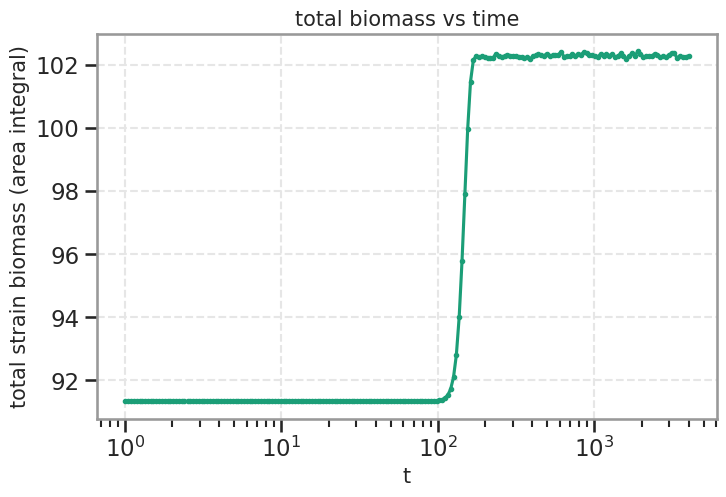

In [9]:
total = biomass.sum(axis=(1, 2)) * dx * dx   # spatial integral
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, total, marker='o', ms=3, color=(27/255, 158/255, 119/255))
ax.set_xscale('log')
ax.set_xlabel('t'); ax.set_ylabel('total strain biomass (area integral)')
ax.set_title('total biomass vs time')
plt.show()

## 8. Biomass field at log-spaced times

Ten representative snapshots (subsampled from the 200), each on its own colour scale.

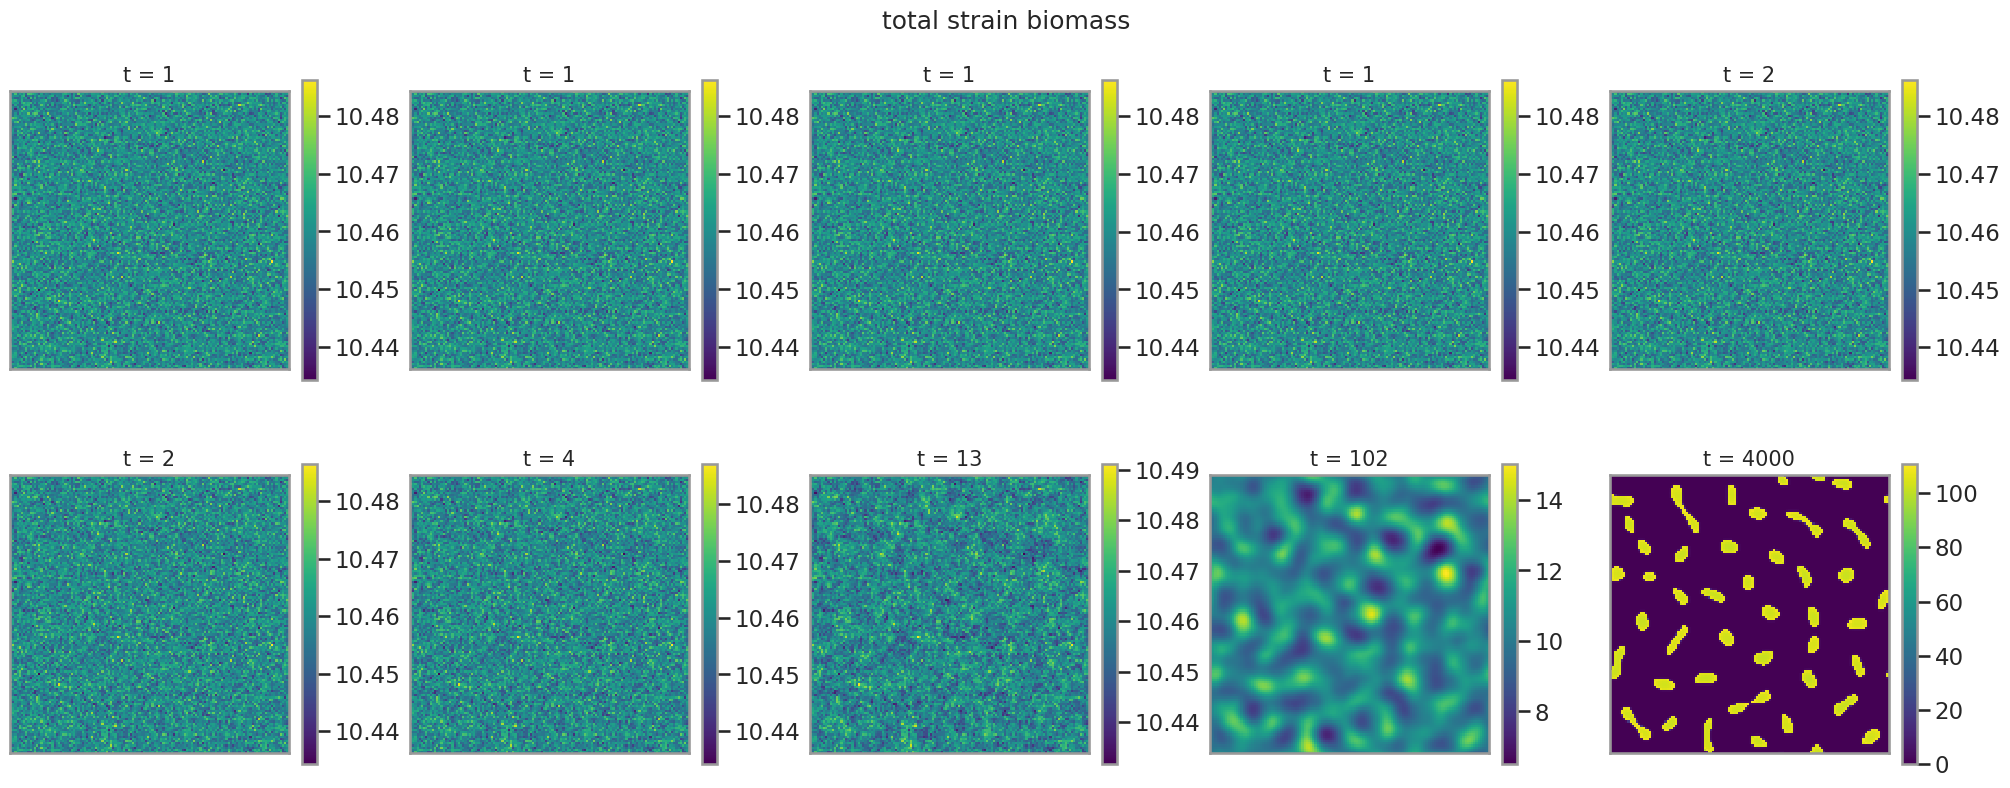

In [10]:
idx = np.unique(np.round(np.logspace(0, np.log10(t.size - 1), 10)).astype(int))
x = np.arange(nx) * dx; y = np.arange(ny) * dx
fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)
for ax, k in zip(axes.ravel(), idx):
    im = ax.pcolormesh(x, y, biomass[k], cmap='viridis', shading='auto')
    ax.set_title(f't = {t[k]:.0f}'); ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.8)
for ax in axes.ravel()[len(idx):]:
    ax.axis('off')
fig.suptitle('total strain biomass', fontsize=18)
plt.show()

## 9. Horizontal slice through the biomass field

Cut along the mid-row in y, overlaid at several times.

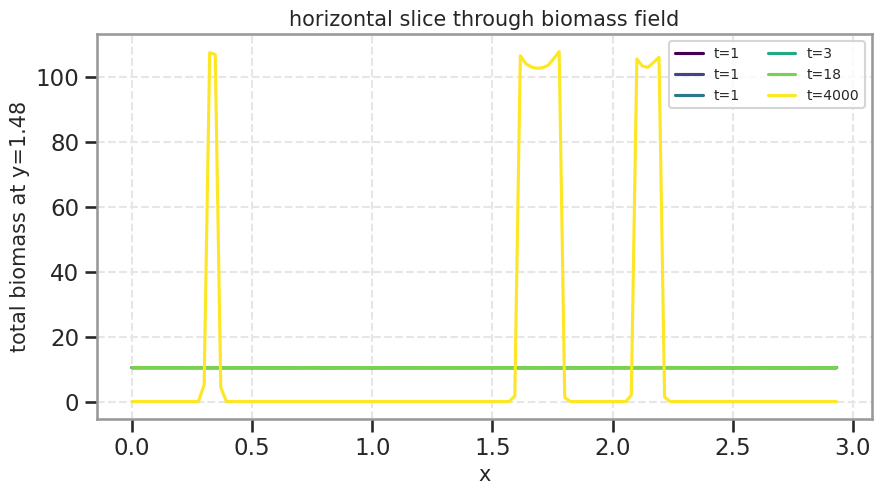

In [11]:
yc = ny // 2
sel = np.unique(np.round(np.logspace(0, np.log10(t.size - 1), 6)).astype(int))
x = np.arange(nx) * dx
cmap = plt.get_cmap('viridis')
fig, ax = plt.subplots(figsize=(10, 5))
for j, k in enumerate(sel):
    ax.plot(x, biomass[k, yc, :], color=cmap(j / max(len(sel) - 1, 1)), label=f't={t[k]:.0f}')
ax.set_xlabel('x'); ax.set_ylabel(f'total biomass at y={yc*dx:.2f}')
ax.set_title('horizontal slice through biomass field')
ax.legend(fontsize=10, ncol=2)
plt.show()